# Fase 2: Exploratory Data Analysis

Este notebook desarrolla la fase de EDA del proyecto de prediccion de retrasos de vuelos en EEUU.

Objetivos del notebook:
- realizar el EDA principal sobre `data/samples/eda_2023.parquet`
- hacer una comparacion ligera con `data/samples/eda_2024.parquet`
- mantener el foco en la clasificacion binaria con target `delay_15`
- separar el analisis descriptivo general de las observaciones utiles para modelado posterior

Alcance y reglas metodologicas:
- `ARR_DELAY` se usa aqui solo de forma descriptiva; no se utilizara como feature del problema de clasificacion
- no se regeneran datasets ni se modifica ningun artefacto dentro de `data/`
- no se altera la metodologia temporal ya fijada en el proyecto

## Marco metodologico

La metodologia temporal del proyecto se mantiene intacta:
- `train_2023`: meses 1 a 9 de 2023
- `valid_2023`: meses 10 a 12 de 2023
- `test_2024`: todo 2024

Este notebook no entrena modelos ni rehace el preprocesado. Su funcion es documentar patrones descriptivos y senales exploratorias que puedan orientar la fase posterior de clasificacion sin introducir leakage.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["figure.max_open_warning"] = 0

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PRIMARY = "#1f4e79"
SECONDARY = "#c2410c"
ACCENT = "#2f855a"
NEUTRAL = "#4b5563"

SAMPLES_DIR = Path("data/samples")
EDA_2023_PATH = SAMPLES_DIR / "eda_2023.parquet"
EDA_2024_PATH = SAMPLES_DIR / "eda_2024.parquet"

In [2]:
MONTH_LABELS = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
DAY_LABELS = {
    1: "Lun", 2: "Mar", 3: "Mie", 4: "Jue", 5: "Vie", 6: "Sab", 7: "Dom"
}

def load_eda_sample(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"No se encontro el archivo esperado: {path}")

    df = pd.read_parquet(path).copy()
    df["month_name"] = pd.Categorical(
        df["MONTH"].map(MONTH_LABELS),
        categories=[MONTH_LABELS[idx] for idx in range(1, 13)],
        ordered=True,
    )
    df["day_name"] = pd.Categorical(
        df["DAY_OF_WEEK"].map(DAY_LABELS),
        categories=[DAY_LABELS[idx] for idx in range(1, 8)],
        ordered=True,
    )
    df["scheduled_hour"] = (df["CRS_DEP_TIME"] // 100).astype("int16")
    return df

def dataset_summary(df: pd.DataFrame, sample_name: str) -> dict:
    return {
        "sample": sample_name,
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "delay_rate_pct": round(df["delay_15"].mean() * 100, 2),
    }

def delay_profile(
    df: pd.DataFrame,
    group_col: str,
    min_flights: int = 0,
    sort_by_rate: bool = False,
    ascending: bool = False,
) -> pd.DataFrame:
    profile = (
        df.groupby(group_col, observed=False)["delay_15"]
        .agg(flights="size", delay_rate="mean")
        .reset_index()
    )
    if min_flights > 0:
        profile = profile.loc[profile["flights"] >= min_flights].copy()
    profile["delay_rate_pct"] = profile["delay_rate"] * 100
    if sort_by_rate:
        profile = profile.sort_values("delay_rate_pct", ascending=ascending)
    return profile

def top_volume_profile(df: pd.DataFrame, group_col: str, top_n: int = 15) -> pd.DataFrame:
    profile = delay_profile(df, group_col)
    top_categories = profile.nlargest(top_n, "flights")[group_col].tolist()
    return (
        profile.loc[profile[group_col].isin(top_categories)]
        .sort_values("delay_rate_pct", ascending=False)
        .reset_index(drop=True)
    )

def categorical_rarity(df: pd.DataFrame, group_col: str) -> dict:
    counts = df[group_col].value_counts()
    return {
        "variable": group_col,
        "n_unique": int(counts.size),
        "median_freq": int(counts.median()),
        "cats_le_100": int((counts <= 100).sum()),
        "cats_le_500": int((counts <= 500).sum()),
    }

eda_2023 = load_eda_sample(EDA_2023_PATH)
eda_2024 = load_eda_sample(EDA_2024_PATH)

block_order = sorted(set(eda_2023["DEP_TIME_BLK"]).union(set(eda_2024["DEP_TIME_BLK"])))
for df in (eda_2023, eda_2024):
    df["DEP_TIME_BLK"] = pd.Categorical(df["DEP_TIME_BLK"], categories=block_order, ordered=True)

## 1. Carga de datos y revision inicial

In [3]:
overview = pd.DataFrame(
    [
        dataset_summary(eda_2023, "eda_2023"),
        dataset_summary(eda_2024, "eda_2024"),
    ]
)
display(overview)

dtype_summary = pd.DataFrame(
    {
        "column": eda_2023.columns,
        "dtype": eda_2023.dtypes.astype(str).values,
        "n_unique": [eda_2023[col].nunique() for col in eda_2023.columns],
    }
).sort_values(["dtype", "column"]).reset_index(drop=True)
display(dtype_summary)

quality_checks = pd.DataFrame(
    [
        {"check": "Valores nulos totales", "value": int(eda_2023.isna().sum().sum())},
        {"check": "Filas duplicadas", "value": int(eda_2023.duplicated().sum())},
        {"check": "Vuelos cancelados", "value": int((eda_2023["CANCELLED"] != 0).sum())},
        {"check": "Vuelos desviados", "value": int((eda_2023["DIVERTED"] != 0).sum())},
    ]
)
display(quality_checks)

display(eda_2023.head())

,sample,rows,cols,memory_mb,delay_rate_pct
0,eda_2023,674340,20,50.81,20.56
1,eda_2024,696527,20,40.52,20.82


,column,dtype,n_unique
0,CRS_DEP_TIME,Int32,1291
1,DEP_TIME_BLK,category,19
2,day_name,category,7
3,month_name,category,12
4,ARR_DELAY,float32,1241
5,DISTANCE,float32,1567
6,YEAR,int16,1
7,scheduled_hour,int16,24
8,CANCELLED,int8,1
9,DAY_OF_MONTH,int8,31


,check,value
0,Valores nulos totales,0
1,Filas duplicadas,1
2,Vuelos cancelados,0
3,Vuelos desviados,0


,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,ORIGIN_STATE_ABR,DEST,DEST_STATE_ABR,CRS_DEP_TIME,DEP_TIME_BLK,ARR_DELAY,CANCELLED,DIVERTED,DISTANCE,DISTANCE_GROUP,delay_15,month_name,day_name,scheduled_hour
0,2023,5,5,5,9E,ORF,VA,DTW,MI,1300,1300-1359,-15.00,0,0,529.00,3,0,May,Vie,13
1,2023,1,10,2,OO,RNO,NV,SFO,CA,1605,1600-1659,-28.00,0,0,192.00,1,0,Jan,Mar,16
2,2023,10,11,3,AA,DFW,TX,JAX,FL,1546,1500-1559,-17.00,0,0,918.00,4,0,Oct,Mie,15
3,2023,12,28,4,OO,DAY,OH,ORD,IL,1200,1200-1259,-2.00,0,0,240.00,1,0,Dec,Jue,12
4,2023,12,21,4,NK,IND,IN,FLL,FL,1111,1100-1159,-16.00,0,0,"1,005.00",5,0,Dec,Jue,11


**Lectura inicial.** `eda_2023` contiene 674,340 vuelos y `eda_2024` 696,527. En la muestra de 2023 no aparecen nulos, cancelaciones ni desvios, lo que es coherente con el preprocesado ya fijado. Tambien aparece 1 fila duplicada en la muestra de EDA; se documenta, pero no se altera porque el alcance de esta fase no incluye modificar artefactos ya generados.

## 2. Analisis univariante

,flights,share_pct
delay_15,,
delay_15 = 0,535670,79.44
delay_15 = 1,138670,20.56


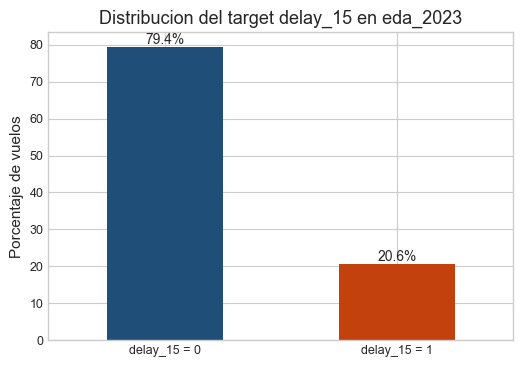

In [4]:
target_distribution = (
    eda_2023["delay_15"]
    .value_counts()
    .sort_index()
    .rename(index={0: "delay_15 = 0", 1: "delay_15 = 1"})
    .rename("flights")
    .to_frame()
)
target_distribution["share_pct"] = 100 * target_distribution["flights"] / len(eda_2023)
display(target_distribution)

fig, ax = plt.subplots(figsize=(6, 4))
target_distribution["share_pct"].plot(kind="bar", color=[PRIMARY, SECONDARY], ax=ax)
ax.set_title("Distribucion del target delay_15 en eda_2023")
ax.set_ylabel("Porcentaje de vuelos")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()
plt.close(fig)

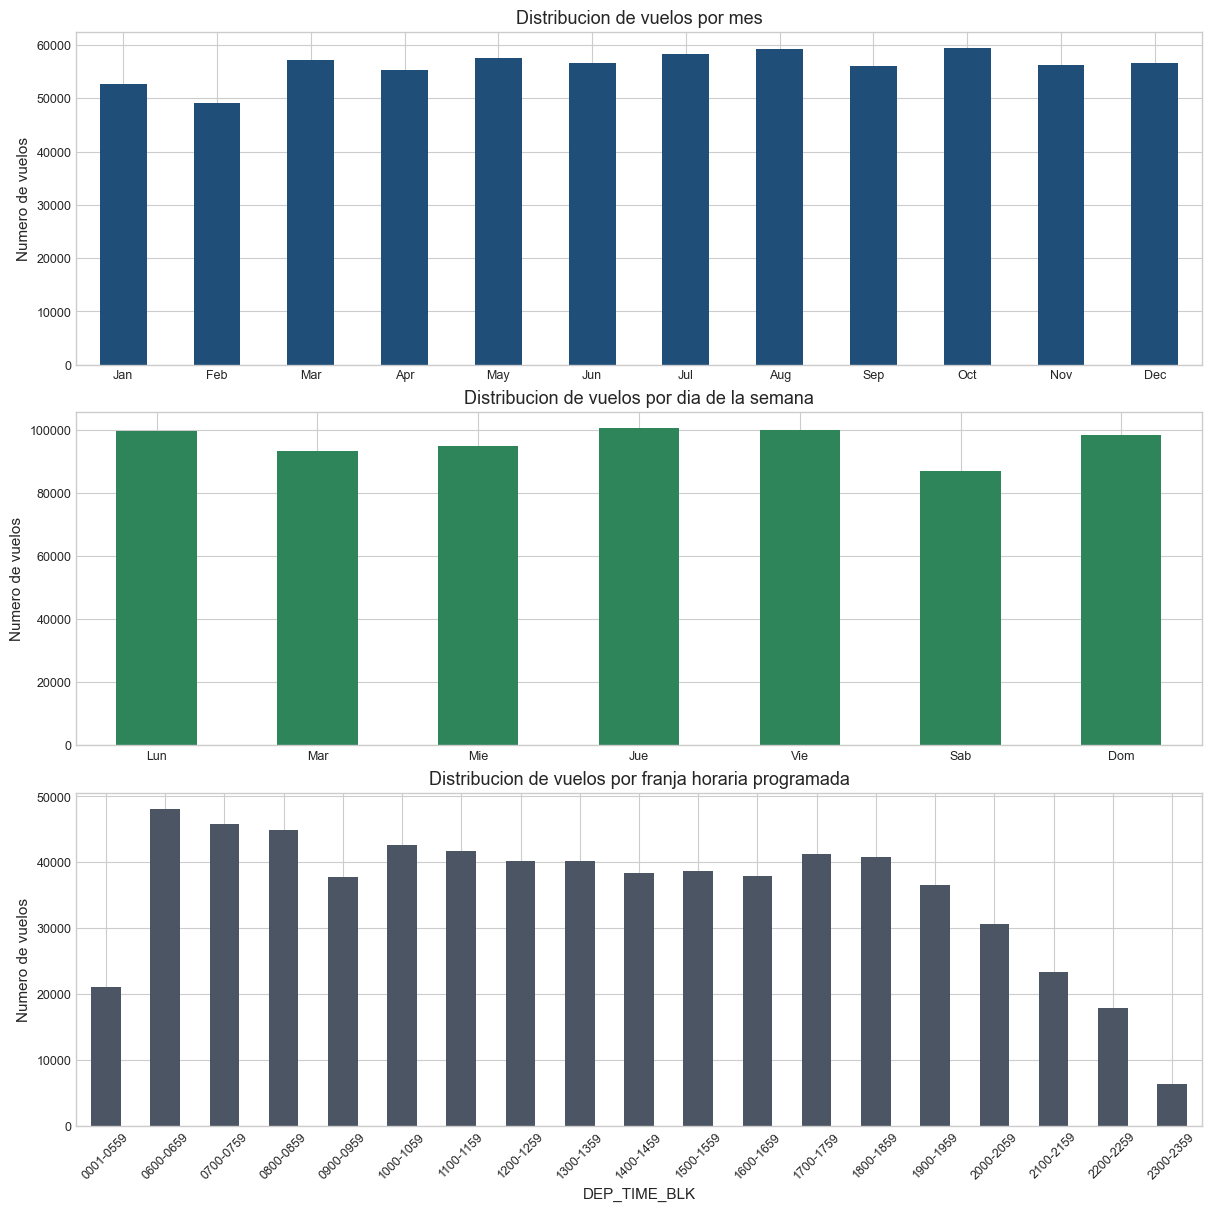

In [5]:
month_counts = eda_2023["month_name"].value_counts().sort_index()
day_counts = eda_2023["day_name"].value_counts().sort_index()
block_counts = eda_2023["DEP_TIME_BLK"].value_counts().sort_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

month_counts.plot(kind="bar", color=PRIMARY, ax=axes[0])
axes[0].set_title("Distribucion de vuelos por mes")
axes[0].set_xlabel("")
axes[0].set_ylabel("Numero de vuelos")
axes[0].tick_params(axis="x", rotation=0)

day_counts.plot(kind="bar", color=ACCENT, ax=axes[1])
axes[1].set_title("Distribucion de vuelos por dia de la semana")
axes[1].set_xlabel("")
axes[1].set_ylabel("Numero de vuelos")
axes[1].tick_params(axis="x", rotation=0)

block_counts.plot(kind="bar", color=NEUTRAL, ax=axes[2])
axes[2].set_title("Distribucion de vuelos por franja horaria programada")
axes[2].set_xlabel("DEP_TIME_BLK")
axes[2].set_ylabel("Numero de vuelos")
axes[2].tick_params(axis="x", rotation=45)

plt.show()
plt.close(fig)

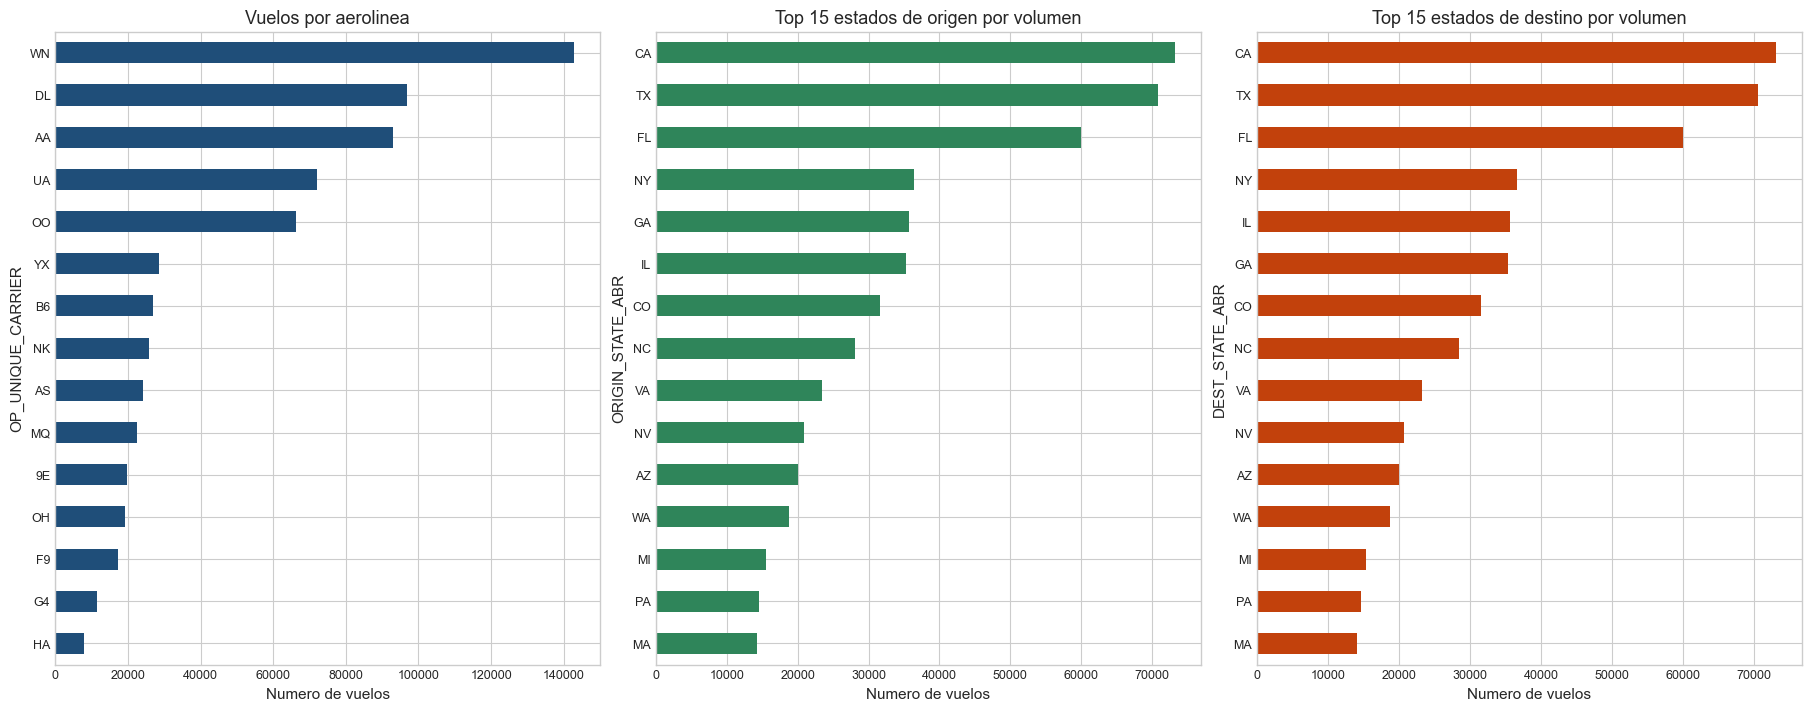

In [6]:
carrier_counts = eda_2023["OP_UNIQUE_CARRIER"].value_counts().sort_values(ascending=True)
origin_state_counts = eda_2023["ORIGIN_STATE_ABR"].value_counts().head(15).sort_values()
dest_state_counts = eda_2023["DEST_STATE_ABR"].value_counts().head(15).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

carrier_counts.plot(kind="barh", color=PRIMARY, ax=axes[0])
axes[0].set_title("Vuelos por aerolinea")
axes[0].set_xlabel("Numero de vuelos")
axes[0].set_ylabel("OP_UNIQUE_CARRIER")

origin_state_counts.plot(kind="barh", color=ACCENT, ax=axes[1])
axes[1].set_title("Top 15 estados de origen por volumen")
axes[1].set_xlabel("Numero de vuelos")
axes[1].set_ylabel("ORIGIN_STATE_ABR")

dest_state_counts.plot(kind="barh", color=SECONDARY, ax=axes[2])
axes[2].set_title("Top 15 estados de destino por volumen")
axes[2].set_xlabel("Numero de vuelos")
axes[2].set_ylabel("DEST_STATE_ABR")

plt.show()
plt.close(fig)

,DISTANCE
count,"674,340.00"
mean,834.21
std,599.88
min,31.00
1%,100.00
5%,177.00
25%,399.00
50%,679.00
75%,"1,069.00"
95%,"2,206.00"


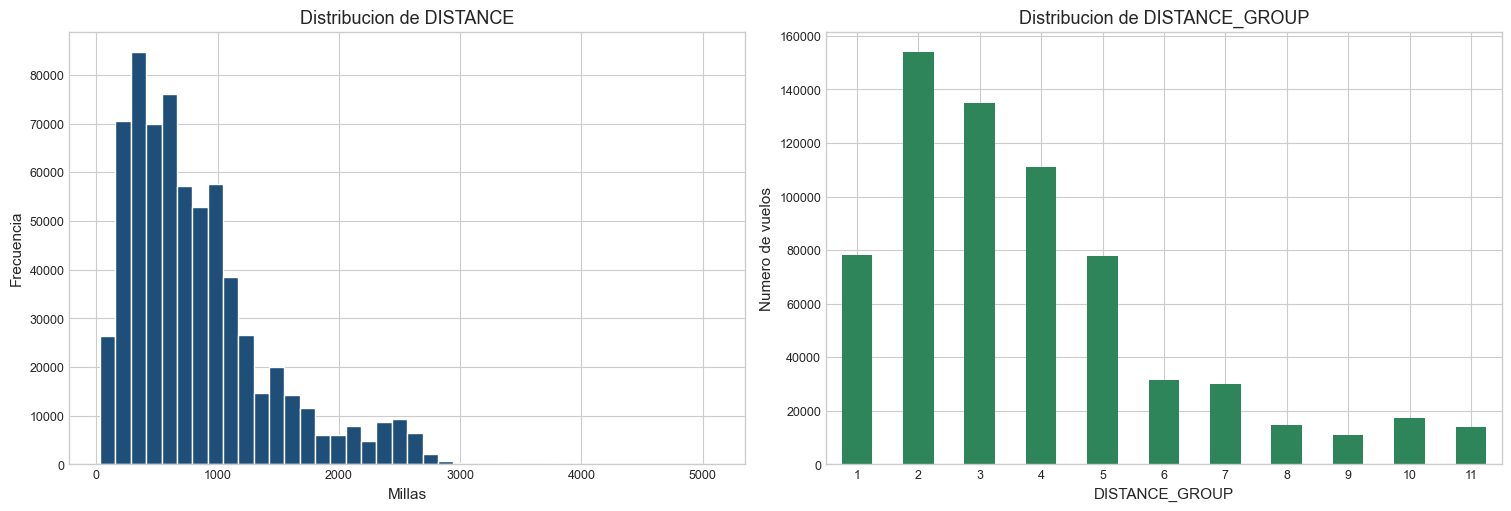

In [7]:
distance_summary = eda_2023["DISTANCE"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("DISTANCE")
display(distance_summary)

distance_group_counts = eda_2023["DISTANCE_GROUP"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
eda_2023["DISTANCE"].plot(kind="hist", bins=40, color=PRIMARY, edgecolor="white", ax=axes[0])
axes[0].set_title("Distribucion de DISTANCE")
axes[0].set_xlabel("Millas")
axes[0].set_ylabel("Frecuencia")

distance_group_counts.plot(kind="bar", color=ACCENT, ax=axes[1])
axes[1].set_title("Distribucion de DISTANCE_GROUP")
axes[1].set_xlabel("DISTANCE_GROUP")
axes[1].set_ylabel("Numero de vuelos")
axes[1].tick_params(axis="x", rotation=0)

plt.show()
plt.close(fig)

`ARR_DELAY` se analiza solo para describir el fenomeno de retraso y la forma de su distribucion. No se utilizara en este notebook para justificar variables predictoras del problema de clasificacion.

,ARR_DELAY
count,"674,340.00"
mean,6.60
std,57.09
min,-94.00
1%,-37.00
5%,-27.00
25%,-15.00
50%,-6.00
75%,9.00
95%,78.00


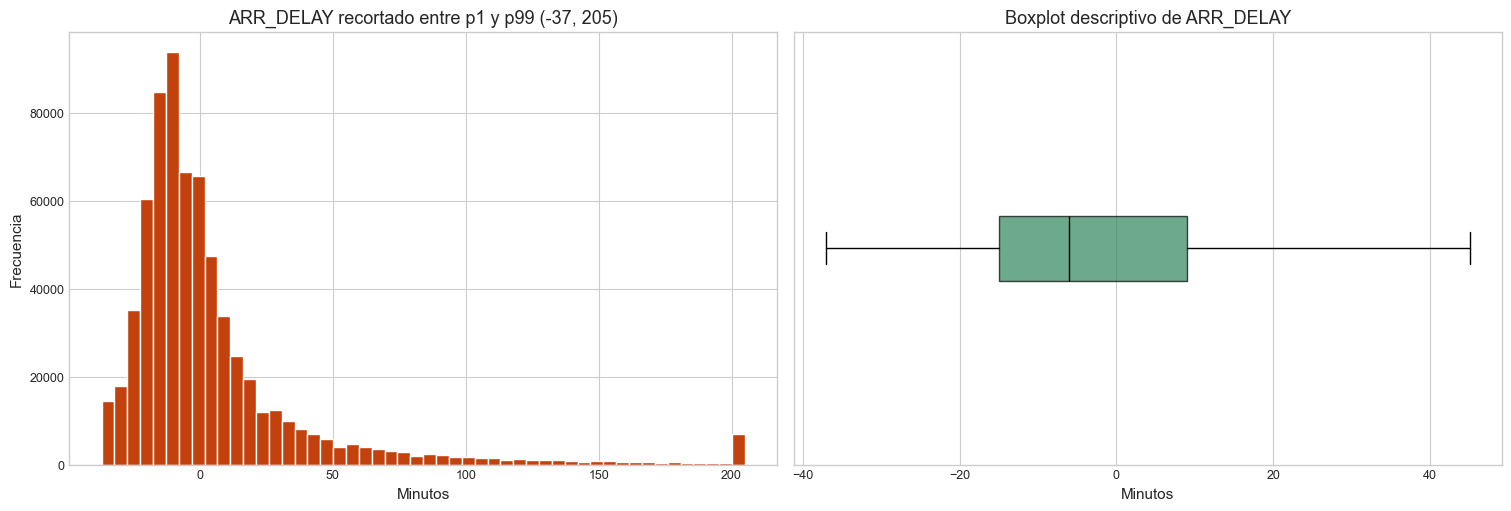

In [8]:
arr_delay_summary = eda_2023["ARR_DELAY"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame("ARR_DELAY")
display(arr_delay_summary)

arr_p01 = eda_2023["ARR_DELAY"].quantile(0.01)
arr_p99 = eda_2023["ARR_DELAY"].quantile(0.99)
arr_delay_clipped = eda_2023["ARR_DELAY"].clip(lower=arr_p01, upper=arr_p99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
arr_delay_clipped.plot(kind="hist", bins=50, color=SECONDARY, edgecolor="white", ax=axes[0])
axes[0].set_title(f"ARR_DELAY recortado entre p1 y p99 ({arr_p01:.0f}, {arr_p99:.0f})")
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot(
    arr_delay_clipped,
    vert=False,
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": ACCENT, "alpha": 0.7},
    medianprops={"color": "black"},
)
axes[1].set_title("Boxplot descriptivo de ARR_DELAY")
axes[1].set_xlabel("Minutos")
axes[1].set_yticks([])

plt.show()
plt.close(fig)

**Lectura del bloque univariante.** La muestra presenta un desbalance moderado en `delay_15`, un patron temporal visible por mes y por franja horaria, y una distribucion de `ARR_DELAY` claramente asimetrica con cola derecha larga. `ORIGIN` y `DEST` no se visualizan completos en este bloque porque su cardinalidad es alta y seria poco legible; se retomaran despues desde una perspectiva mas util para modelado.

## 3. Analisis bivariante respecto a delay_15

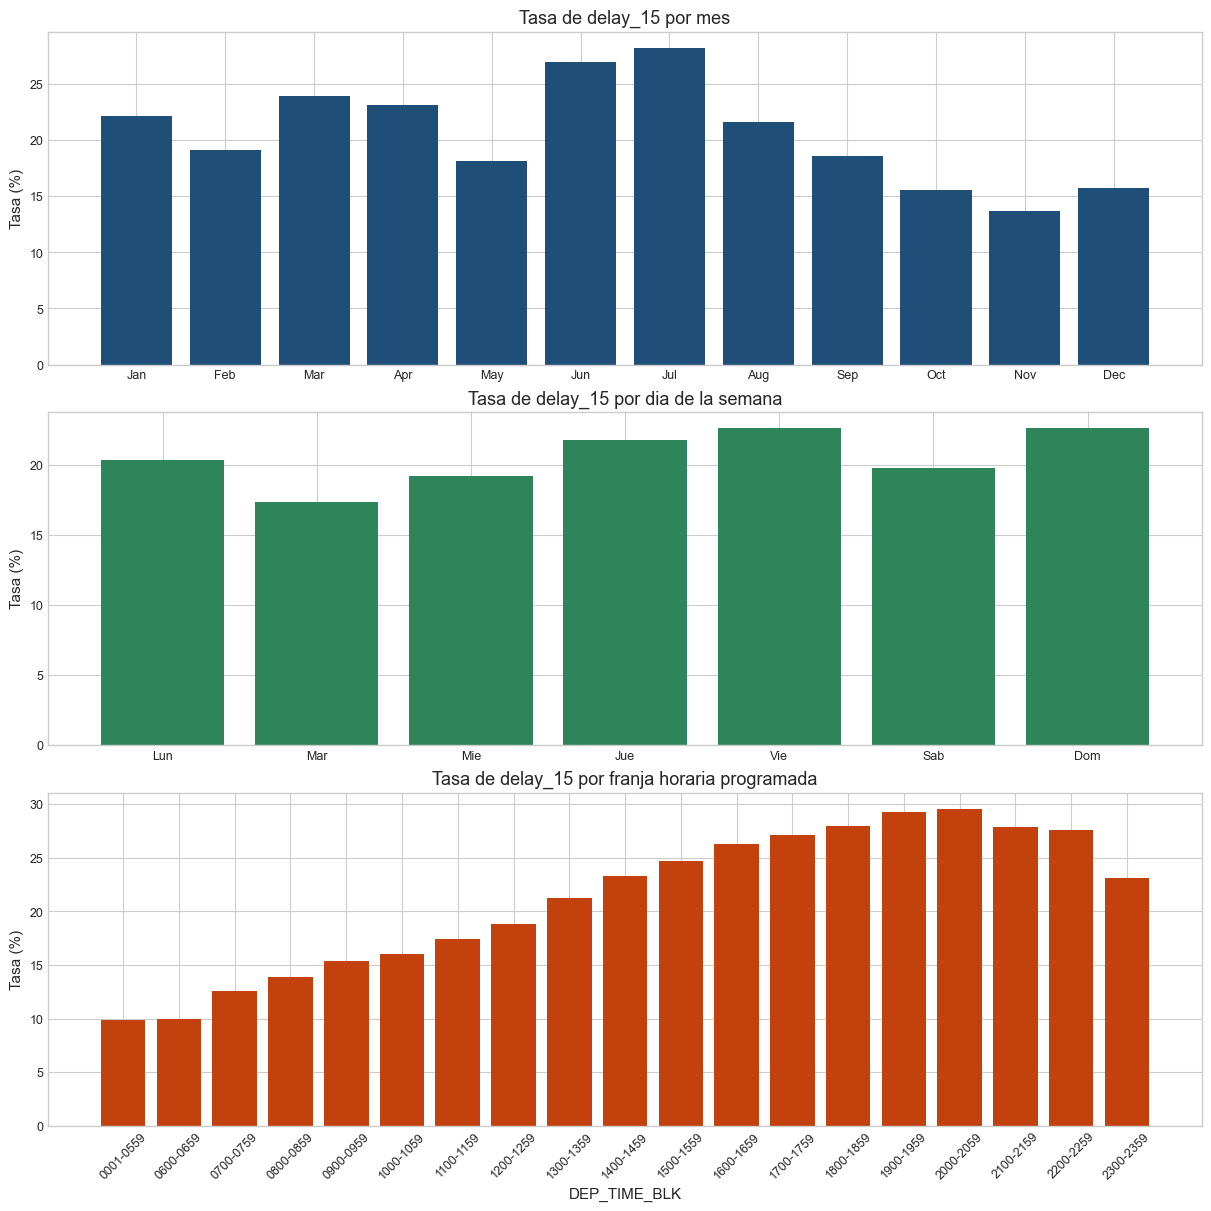

In [9]:
month_delay = delay_profile(eda_2023, "month_name")
day_delay = delay_profile(eda_2023, "day_name")
block_delay = delay_profile(eda_2023, "DEP_TIME_BLK")

fig, axes = plt.subplots(3, 1, figsize=(12, 12), constrained_layout=True)

axes[0].bar(month_delay["month_name"].astype(str), month_delay["delay_rate_pct"], color=PRIMARY)
axes[0].set_title("Tasa de delay_15 por mes")
axes[0].set_ylabel("Tasa (%)")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(day_delay["day_name"].astype(str), day_delay["delay_rate_pct"], color=ACCENT)
axes[1].set_title("Tasa de delay_15 por dia de la semana")
axes[1].set_ylabel("Tasa (%)")
axes[1].tick_params(axis="x", rotation=0)

axes[2].bar(block_delay["DEP_TIME_BLK"].astype(str), block_delay["delay_rate_pct"], color=SECONDARY)
axes[2].set_title("Tasa de delay_15 por franja horaria programada")
axes[2].set_ylabel("Tasa (%)")
axes[2].set_xlabel("DEP_TIME_BLK")
axes[2].tick_params(axis="x", rotation=45)

plt.show()
plt.close(fig)

,OP_UNIQUE_CARRIER,flights,delay_rate_pct
5,F9,17376,31.42
3,B6,26830,31.08
9,NK,25839,29.25
6,G4,11462,26.16
7,HA,7859,24.51
1,AA,93022,23.06
13,WN,142831,21.89
12,UA,71955,20.41
2,AS,24103,20.16
8,MQ,22375,18.43


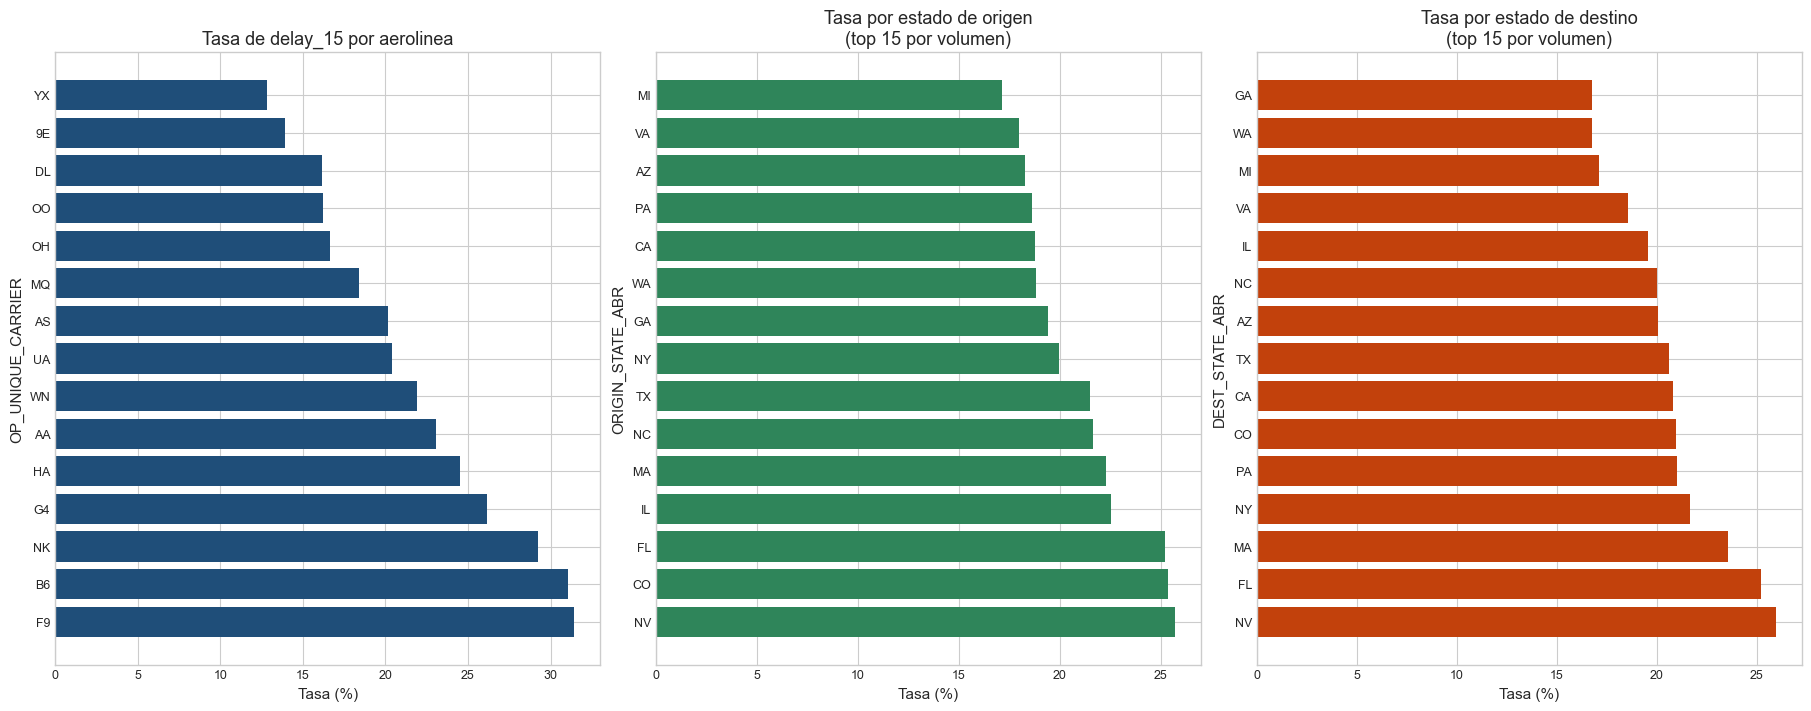

In [10]:
carrier_delay = delay_profile(eda_2023, "OP_UNIQUE_CARRIER", sort_by_rate=True)
origin_state_delay = top_volume_profile(eda_2023, "ORIGIN_STATE_ABR", top_n=15)
dest_state_delay = top_volume_profile(eda_2023, "DEST_STATE_ABR", top_n=15)

display(carrier_delay[["OP_UNIQUE_CARRIER", "flights", "delay_rate_pct"]])

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)

axes[0].barh(carrier_delay["OP_UNIQUE_CARRIER"], carrier_delay["delay_rate_pct"], color=PRIMARY)
axes[0].set_title("Tasa de delay_15 por aerolinea")
axes[0].set_xlabel("Tasa (%)")
axes[0].set_ylabel("OP_UNIQUE_CARRIER")

axes[1].barh(origin_state_delay["ORIGIN_STATE_ABR"], origin_state_delay["delay_rate_pct"], color=ACCENT)
axes[1].set_title("Tasa por estado de origen\n(top 15 por volumen)")
axes[1].set_xlabel("Tasa (%)")
axes[1].set_ylabel("ORIGIN_STATE_ABR")

axes[2].barh(dest_state_delay["DEST_STATE_ABR"], dest_state_delay["delay_rate_pct"], color=SECONDARY)
axes[2].set_title("Tasa por estado de destino\n(top 15 por volumen)")
axes[2].set_xlabel("Tasa (%)")
axes[2].set_ylabel("DEST_STATE_ABR")

plt.show()
plt.close(fig)

,DISTANCE_GROUP,flights,delay_rate_pct
0,1,78135,18.08
1,2,153860,18.45
2,3,134925,20.16
3,4,111092,21.83
4,5,77768,23.66
5,6,31369,20.73
6,7,29892,23.03
7,8,14696,22.30
8,9,10949,22.58
9,10,17510,22.42


,count,mean,50%,std
delay_15,,,,
delay_15 = 0,"535,670.00",822.80,667.00,597.03
delay_15 = 1,"138,670.00",878.30,746.00,608.78


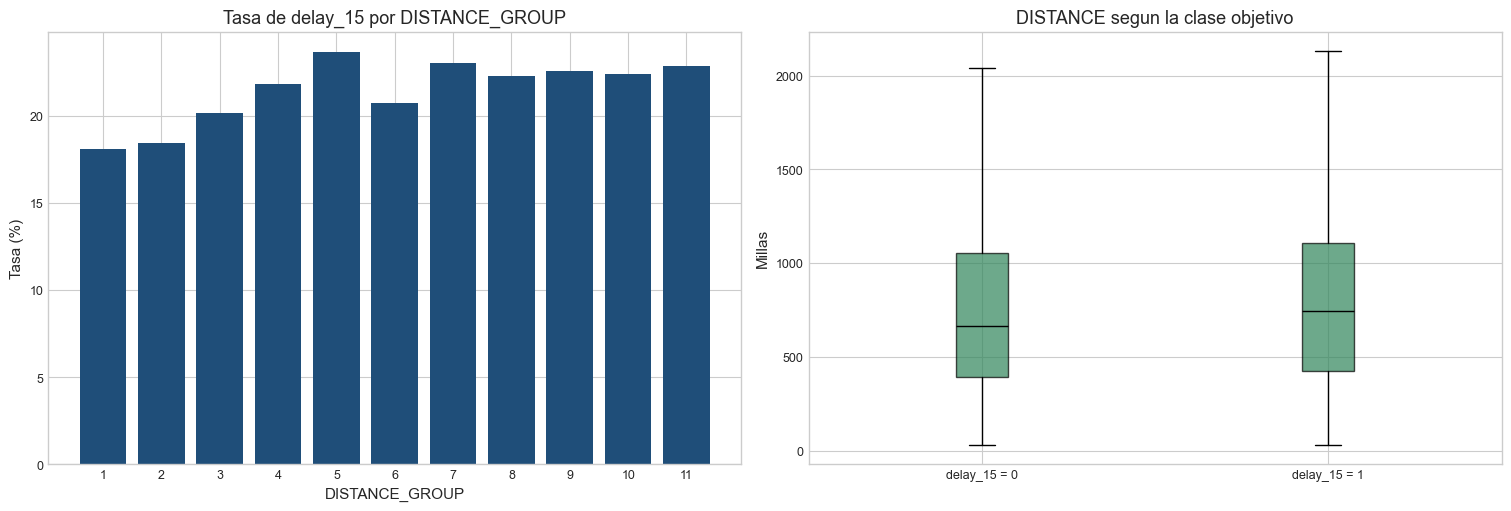

In [11]:
distance_group_delay = delay_profile(eda_2023, "DISTANCE_GROUP")
distance_by_target = (
    eda_2023.groupby("delay_15")["DISTANCE"]
    .describe()[["count", "mean", "50%", "std"]]
    .rename(index={0: "delay_15 = 0", 1: "delay_15 = 1"})
)
display(distance_group_delay[["DISTANCE_GROUP", "flights", "delay_rate_pct"]])
display(distance_by_target)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].bar(distance_group_delay["DISTANCE_GROUP"].astype(str), distance_group_delay["delay_rate_pct"], color=PRIMARY)
axes[0].set_title("Tasa de delay_15 por DISTANCE_GROUP")
axes[0].set_xlabel("DISTANCE_GROUP")
axes[0].set_ylabel("Tasa (%)")
axes[0].tick_params(axis="x", rotation=0)

axes[1].boxplot(
    [
        eda_2023.loc[eda_2023["delay_15"] == 0, "DISTANCE"],
        eda_2023.loc[eda_2023["delay_15"] == 1, "DISTANCE"],
    ],
    labels=["delay_15 = 0", "delay_15 = 1"],
    showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": ACCENT, "alpha": 0.7},
    medianprops={"color": "black"},
)
axes[1].set_title("DISTANCE segun la clase objetivo")
axes[1].set_ylabel("Millas")

plt.show()
plt.close(fig)

**Lectura del bloque bivariante.** La tasa de retraso no es homogenea: crece claramente a medida que avanza el dia, cambia de forma apreciable entre aerolineas y muestra diferencias moderadas por distancia y por estado. Para origen y destino se priorizan estados y no aeropuertos individuales, porque asi se conserva interpretabilidad sin caer en visualizaciones inmanejables.

## 4. Hallazgos orientados a modelado

In [12]:
class_balance = pd.DataFrame(
    {
        "metric": ["Delay >= 15 min", "Delay < 15 min", "Ratio clase positiva / negativa"],
        "value": [
            round(eda_2023["delay_15"].mean() * 100, 2),
            round((1 - eda_2023["delay_15"].mean()) * 100, 2),
            round(eda_2023["delay_15"].sum() / (len(eda_2023) - eda_2023["delay_15"].sum()), 3),
        ],
    }
)
display(class_balance)

signal_rows = []
for variable in [
    "MONTH",
    "DAY_OF_WEEK",
    "DEP_TIME_BLK",
    "OP_UNIQUE_CARRIER",
    "ORIGIN_STATE_ABR",
    "DEST_STATE_ABR",
    "DISTANCE_GROUP",
]:
    profile = delay_profile(eda_2023, variable)
    signal_rows.append(
        {
            "variable": variable,
            "n_levels": int(profile.shape[0]),
            "min_delay_rate_pct": round(profile["delay_rate_pct"].min(), 2),
            "max_delay_rate_pct": round(profile["delay_rate_pct"].max(), 2),
            "range_pp": round(profile["delay_rate_pct"].max() - profile["delay_rate_pct"].min(), 2),
        }
    )
signal_summary = pd.DataFrame(signal_rows).sort_values("range_pp", ascending=False).reset_index(drop=True)
display(signal_summary)

rarity_summary = pd.DataFrame(
    [
        categorical_rarity(eda_2023, "OP_UNIQUE_CARRIER"),
        categorical_rarity(eda_2023, "ORIGIN_STATE_ABR"),
        categorical_rarity(eda_2023, "DEST_STATE_ABR"),
        categorical_rarity(eda_2023, "DEP_TIME_BLK"),
        categorical_rarity(eda_2023, "ORIGIN"),
        categorical_rarity(eda_2023, "DEST"),
    ]
).sort_values("n_unique", ascending=False).reset_index(drop=True)
display(rarity_summary)

,metric,value
0,Delay >= 15 min,20.56
1,Delay < 15 min,79.44
2,Ratio clase positiva / negativa,0.26


,variable,n_levels,min_delay_rate_pct,max_delay_rate_pct,range_pp
0,DEP_TIME_BLK,19,9.88,29.61,19.73
1,OP_UNIQUE_CARRIER,15,12.85,31.42,18.57
2,DEST_STATE_ABR,52,14.28,32.02,17.74
3,ORIGIN_STATE_ABR,52,8.73,25.71,16.98
4,MONTH,12,13.66,28.25,14.59
5,DISTANCE_GROUP,11,18.08,23.66,5.58
6,DAY_OF_WEEK,7,17.34,22.62,5.28


,variable,n_unique,median_freq,cats_le_100,cats_le_500
0,ORIGIN,349,276,115,216
1,DEST,349,282,116,216
2,DEST_STATE_ABR,52,6217,0,2
3,ORIGIN_STATE_ABR,52,6273,0,2
4,DEP_TIME_BLK,19,38659,0,0
5,OP_UNIQUE_CARRIER,15,25839,0,0


Observaciones provisionales para la siguiente fase:

- El target presenta desbalanceo moderado, asi que conviene vigilar metricas mas informativas que la accuracy simple.
- `MONTH`, `DEP_TIME_BLK`, `OP_UNIQUE_CARRIER` y `DISTANCE_GROUP` muestran senal aparente respecto a `delay_15`.
- `ORIGIN` y `DEST` tienen mucha cardinalidad y una cola larga de categorias poco frecuentes, por lo que requeriran tratamiento cuidadoso.
- `ORIGIN_STATE_ABR` y `DEST_STATE_ABR` parecen buenos candidatos a una vista mas agregada y estable que el nivel aeropuerto.
- Las senales temporales son visibles y coherentes con la logica del problema, pero siguen siendo exploratorias; aqui no se cierran decisiones finales de variables ni de transformaciones.
- La muestra disponible excluye cancelaciones y desvios, asi que el problema queda centrado en retrasos de llegada entre vuelos efectivamente completados.

## 5. Comparacion ligera 2023 vs 2024

,sample,rows,delay_rate_pct
0,eda_2023,674340,20.56
1,eda_2024,696527,20.82


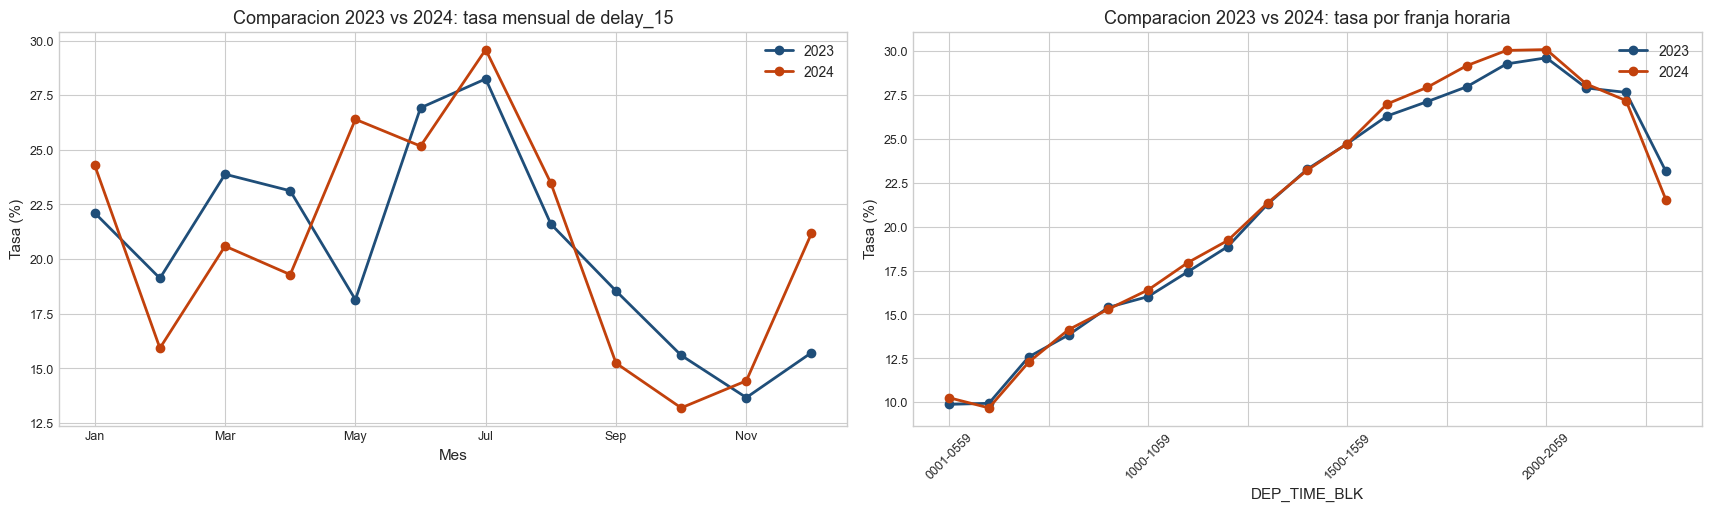

In [13]:
overall_compare = pd.DataFrame(
    {
        "sample": ["eda_2023", "eda_2024"],
        "rows": [len(eda_2023), len(eda_2024)],
        "delay_rate_pct": [eda_2023["delay_15"].mean() * 100, eda_2024["delay_15"].mean() * 100],
    }
)
display(overall_compare)

month_compare = pd.concat(
    [
        delay_profile(eda_2023, "month_name").set_index("month_name")["delay_rate_pct"].rename("2023"),
        delay_profile(eda_2024, "month_name").set_index("month_name")["delay_rate_pct"].rename("2024"),
    ],
    axis=1,
)
block_compare = pd.concat(
    [
        delay_profile(eda_2023, "DEP_TIME_BLK").set_index("DEP_TIME_BLK")["delay_rate_pct"].rename("2023"),
        delay_profile(eda_2024, "DEP_TIME_BLK").set_index("DEP_TIME_BLK")["delay_rate_pct"].rename("2024"),
    ],
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)

month_compare.plot(marker="o", linewidth=2, ax=axes[0], color=[PRIMARY, SECONDARY])
axes[0].set_title("Comparacion 2023 vs 2024: tasa mensual de delay_15")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Tasa (%)")
axes[0].tick_params(axis="x", rotation=0)

block_compare.plot(marker="o", linewidth=2, ax=axes[1], color=[PRIMARY, SECONDARY])
axes[1].set_title("Comparacion 2023 vs 2024: tasa por franja horaria")
axes[1].set_xlabel("DEP_TIME_BLK")
axes[1].set_ylabel("Tasa (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.show()
plt.close(fig)

,2023,2024
OP_UNIQUE_CARRIER,,
MQ,3.32,3.96
AS,3.57,3.39
NK,3.83,3.68
B6,3.98,3.39
YX,4.25,4.28
OO,9.83,10.49
UA,10.67,10.77
AA,13.79,13.83
DL,14.37,14.35


,2023,2024
DISTANCE_GROUP,,
1,18.08,19.29
2,18.45,19.73
3,20.16,20.88
4,21.83,21.46
5,23.66,22.72
6,20.73,21.36
7,23.03,22.49
8,22.30,21.02
9,22.58,21.38


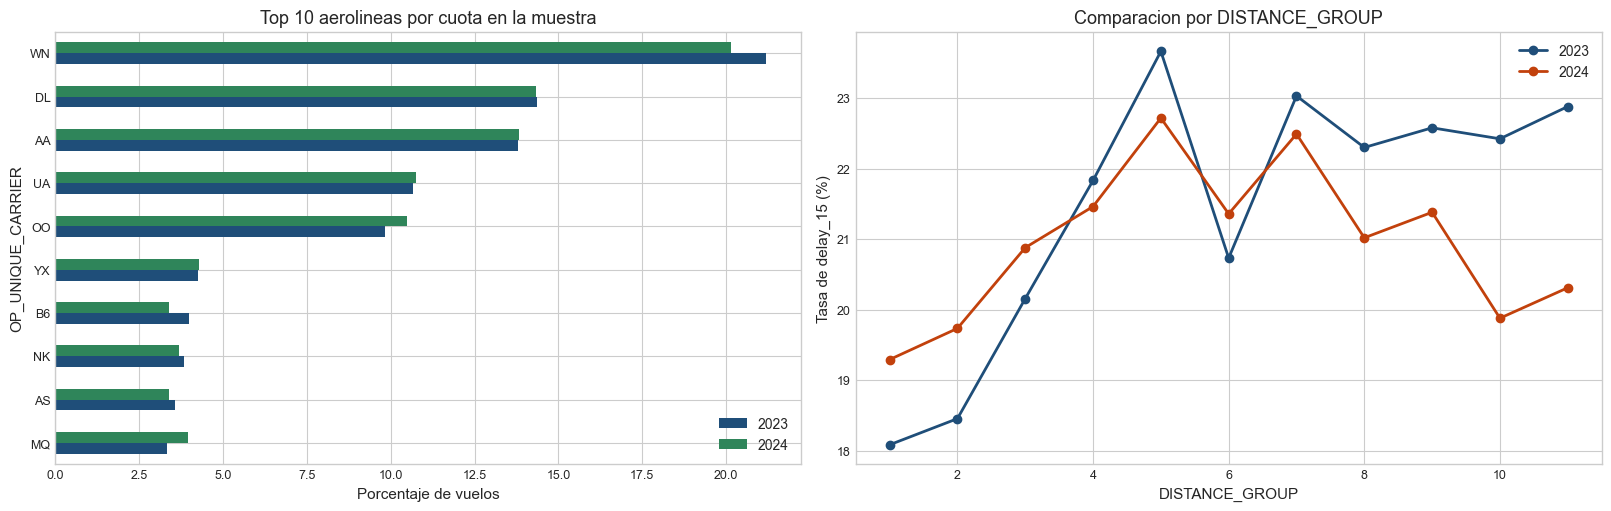

In [14]:
carrier_share_compare = pd.concat(
    [
        (eda_2023["OP_UNIQUE_CARRIER"].value_counts(normalize=True) * 100).rename("2023"),
        (eda_2024["OP_UNIQUE_CARRIER"].value_counts(normalize=True) * 100).rename("2024"),
    ],
    axis=1,
).fillna(0)
top_carriers = carrier_share_compare["2023"].sort_values(ascending=False).head(10).index
carrier_share_top = carrier_share_compare.loc[top_carriers].sort_values("2023", ascending=True)
display(carrier_share_top)

distance_compare = pd.concat(
    [
        delay_profile(eda_2023, "DISTANCE_GROUP").set_index("DISTANCE_GROUP")["delay_rate_pct"].rename("2023"),
        delay_profile(eda_2024, "DISTANCE_GROUP").set_index("DISTANCE_GROUP")["delay_rate_pct"].rename("2024"),
    ],
    axis=1,
)
display(distance_compare)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

carrier_share_top.plot(kind="barh", ax=axes[0], color=[PRIMARY, ACCENT])
axes[0].set_title("Top 10 aerolineas por cuota en la muestra")
axes[0].set_xlabel("Porcentaje de vuelos")
axes[0].set_ylabel("OP_UNIQUE_CARRIER")

distance_compare.plot(marker="o", linewidth=2, ax=axes[1], color=[PRIMARY, SECONDARY])
axes[1].set_title("Comparacion por DISTANCE_GROUP")
axes[1].set_xlabel("DISTANCE_GROUP")
axes[1].set_ylabel("Tasa de delay_15 (%)")
axes[1].tick_params(axis="x", rotation=0)

plt.show()
plt.close(fig)

**Lectura de la comparacion temporal.** La tasa global de `delay_15` se mantiene bastante cercana entre ambos anos, pero hay diferencias visibles por mes y pequenas variaciones en la mezcla por aerolinea. Esto sugiere una estabilidad razonable del fenomeno con cierto `temporal shift`, justo el tipo de situacion para la que tiene sentido conservar la validacion temporal del proyecto.

In [15]:
month_delay_final = delay_profile(eda_2023, "month_name")
carrier_delay_final = delay_profile(eda_2023, "OP_UNIQUE_CARRIER", sort_by_rate=True)
block_delay_final = delay_profile(eda_2023, "DEP_TIME_BLK", sort_by_rate=True)

peak_month_row = month_delay_final.loc[month_delay_final["delay_rate_pct"].idxmax()]
low_month_row = month_delay_final.loc[month_delay_final["delay_rate_pct"].idxmin()]
peak_block_row = block_delay_final.iloc[0]
top_carrier_row = carrier_delay_final.iloc[0]
rare_origins_100 = int((eda_2023["ORIGIN"].value_counts() <= 100).sum())
delay_rate_2023 = eda_2023["delay_15"].mean() * 100
delay_rate_2024 = eda_2024["delay_15"].mean() * 100
delay_diff = delay_rate_2024 - delay_rate_2023

summary_lines = [
    "## 6. Conclusiones finales",
    "",
    f"- En `eda_2023`, `delay_15` presenta un desbalance moderado: **{delay_rate_2023:.1f}%** de los vuelos llegan con al menos 15 minutos de retraso.",
    f"- La senal temporal es clara: el maximo mensual aparece en **{peak_month_row['month_name']}** ({peak_month_row['delay_rate_pct']:.1f}%) y el minimo en **{low_month_row['month_name']}** ({low_month_row['delay_rate_pct']:.1f}%). Por franja horaria, el pico se concentra en **{peak_block_row['DEP_TIME_BLK']}** ({peak_block_row['delay_rate_pct']:.1f}%).",
    f"- Entre variables operativas, `OP_UNIQUE_CARRIER` muestra heterogeneidad relevante; la tasa mas alta observada en la muestra corresponde a **{top_carrier_row['OP_UNIQUE_CARRIER']}** ({top_carrier_row['delay_rate_pct']:.1f}%).",
    f"- `ORIGIN` y `DEST` aportan detalle, pero tambien alta cardinalidad y cola larga de categorias raras; por ejemplo, **{rare_origins_100}** aeropuertos de origen tienen 100 vuelos o menos en `eda_2023`.",
    "- `ARR_DELAY` tiene una distribucion muy asimetrica y con outliers extremos. En este notebook se usa solo para describir el fenomeno y no como predictor del problema de clasificacion.",
    f"- Frente a `eda_2024`, la tasa global de retraso se mantiene cercana (**{delay_rate_2024:.1f}%** en 2024, variacion de **{delay_diff:+.1f} pp**), aunque existen cambios visibles por mes, por bloque horario y por mezcla de aerolineas.",
    "",
    "Este EDA deja preparado el terreno para la siguiente fase de clasificacion sin mezclar descripcion del fenomeno con decisiones finales de modelado.",
]
display(Markdown("\n".join(summary_lines)))

## 6. Conclusiones finales

- En `eda_2023`, `delay_15` presenta un desbalance moderado: **20.6%** de los vuelos llegan con al menos 15 minutos de retraso.
- La senal temporal es clara: el maximo mensual aparece en **Jul** (28.2%) y el minimo en **Nov** (13.7%). Por franja horaria, el pico se concentra en **2000-2059** (29.6%).
- Entre variables operativas, `OP_UNIQUE_CARRIER` muestra heterogeneidad relevante; la tasa mas alta observada en la muestra corresponde a **F9** (31.4%).
- `ORIGIN` y `DEST` aportan detalle, pero tambien alta cardinalidad y cola larga de categorias raras; por ejemplo, **115** aeropuertos de origen tienen 100 vuelos o menos en `eda_2023`.
- `ARR_DELAY` tiene una distribucion muy asimetrica y con outliers extremos. En este notebook se usa solo para describir el fenomeno y no como predictor del problema de clasificacion.
- Frente a `eda_2024`, la tasa global de retraso se mantiene cercana (**20.8%** en 2024, variacion de **+0.3 pp**), aunque existen cambios visibles por mes, por bloque horario y por mezcla de aerolineas.

Este EDA deja preparado el terreno para la siguiente fase de clasificacion sin mezclar descripcion del fenomeno con decisiones finales de modelado.